In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

def create_fake_dataset():
    categories = ['Data Science', 'Software Engineer', 'Web Developer', 'HR', 'Sales', 'Digital Marketing']

    resume_samples = {
        'Data Science': [
            'Python developer with ML, Pandas, Numpy, TensorFlow, SQL experience. 3 years in data analysis',
            'Data Scientist skilled in Machine Learning, Statistics, Python, R, Tableau. Built predictive models',
            'Expert in Python, Scikit-learn, Data Visualization, SQL. Worked on AI projects'
        ],
        'Software Engineer': [
            'Java developer with Spring Boot, Microservices, REST API, MySQL. 4 years backend experience',
            'Software Engineer C++ Java Python. DSA, System Design, Git, Docker experience',
            'Full Stack Java developer. Spring, Hibernate, AWS, Jenkins, Agile methodology'
        ],
        'Web Developer': [
            'Frontend developer React JavaScript HTML CSS. Responsive design, Bootstrap experience',
            'Web developer MERN stack. MongoDB Express React Node.js. Built e-commerce sites',
            'UI/UX developer with HTML5 CSS3 JavaScript. WordPress, PHP, SEO knowledge'
        ],
        'HR': [
            'HR Manager with recruitment, employee relations, payroll, performance management experience',
            'Human Resource professional. Talent acquisition, onboarding, HR policies, labor laws',
            'HR Executive skilled in interviewing, training, employee engagement, compliance'
        ],
        'Sales': [
            'Sales Executive with B2B sales, client relationship, target achievement, CRM experience',
            'Sales Manager. Lead generation, negotiation, market research, 5 years field sales',
            'Retail sales professional. Customer service, product knowledge, sales targets'
        ],
        'Digital Marketing': [
            'Digital Marketer SEO SEM Google Ads Facebook Ads. Content marketing 3 years experience',
            'Social Media Manager. Instagram Facebook LinkedIn campaigns, analytics, growth hacking',
            'Marketing Executive with email marketing, PPC, Google Analytics, brand management'
        ]
    }

    data = []
    for cat, resumes in resume_samples.items():
        for _ in range(50): 
            resume = np.random.choice(resumes)
            exp = np.random.randint(1, 10)
            data.append({'Category': cat, 'Resume_Text': resume, 'Experience': exp})

    return pd.DataFrame(data)

df = create_fake_dataset()
print(f"✅ {df.shape}")
print(df['Category'].value_counts())

✅ (300, 3)
Category
Data Science         50
Software Engineer    50
Web Developer        50
HR                   50
Sales                50
Digital Marketing    50
Name: count, dtype: int64


In [2]:
df['Resume_Text'] = df['Resume_Text'].str.lower().str.replace(r'[^a-zA-Z\s]', '', regex=True)


tfidf = TfidfVectorizer(max_features=500, stop_words='english')
X_tfidf = tfidf.fit_transform(df['Resume_Text']).toarray()

X = np.hstack([X_tfidf, df[['Experience']].values])
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("✅ Data ready for training")

Train: (240, 125), Test: (60, 125)
✅ Data ready for training



Training Logistic Regression...
Logistic Regression - Accuracy: 1.0000, F1: 1.0000

Training Random Forest...
Random Forest - Accuracy: 1.0000, F1: 1.0000

Training Decision Tree...
Decision Tree - Accuracy: 1.0000, F1: 1.0000

MODEL COMPARISON REPORT
                    Accuracy Precision Recall F1 Score
Logistic Regression      1.0       1.0    1.0      1.0
Random Forest            1.0       1.0    1.0      1.0
Decision Tree            1.0       1.0    1.0      1.0


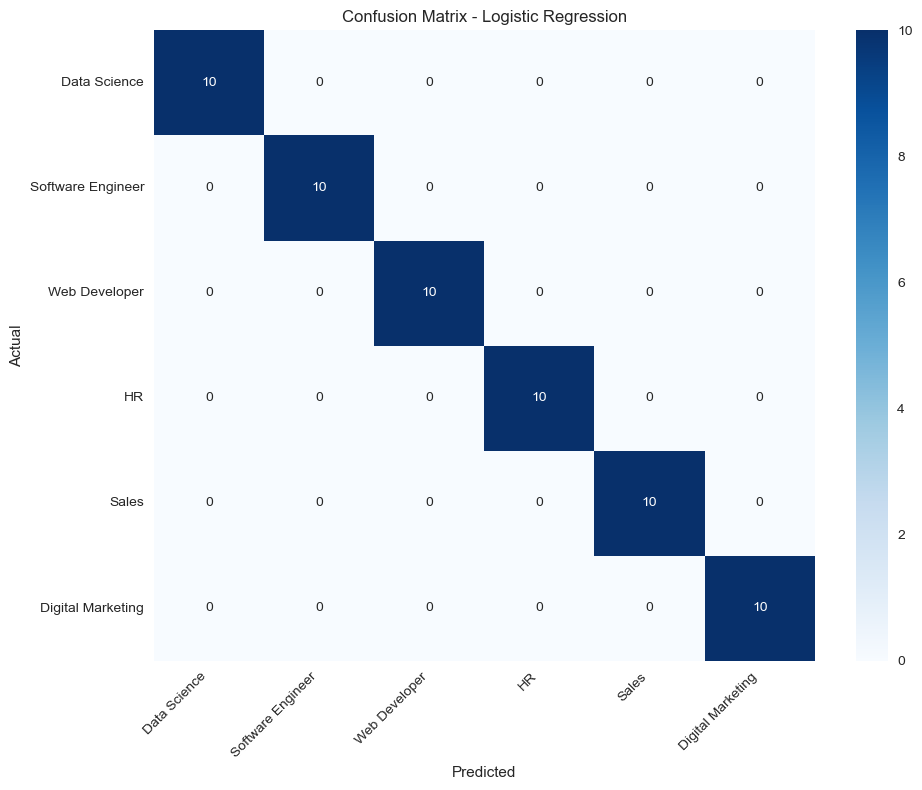


🎉 DONE! Best Model: Logistic Regression
Files created:
1. model_comparison_report.csv
2. confusion_matrix.png
3. best_resume_classifier.pkl
4. tfidf_vectorizer.pkl - for Day 4 Flask


In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1, 'Model': model, 'Pred': y_pred}
    print(f"{name} - Accuracy: {acc:.4f}, F1: {f1:.4f}")

results_df = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(4)
print("\n" + "="*50)
print("MODEL COMPARISON REPORT")
print("="*50)
print(results_df)
results_df.to_csv('model_comparison_report.csv')

best_name = results_df['F1 Score'].idxmax()
best_pred = results[best_name]['Pred']

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['Category'].unique(), yticklabels=df['Category'].unique())
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

for name, info in results.items():
    joblib.dump(info['Model'], f"{name.replace(' ', '_').lower()}_model.pkl")

joblib.dump(results[best_name]['Model'], 'best_resume_classifier.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl') # For Day 4 Flask

print(f"\n🎉 DONE! Best Model: {best_name}")
print("Files created:")
print("1. model_comparison_report.csv")
print("2. confusion_matrix.png")
print("3. best_resume_classifier.pkl")
print("4. tfidf_vectorizer.pkl - for Day 4 Flask")